In [31]:
import wandb
wandb.login()
api = wandb.Api()





# medsegbench
runs = {"patch_icl": {"wandb_name": "8imbu71v"},
        "universeg": {"wandb_name": "5s6x367p"}
}
# totalseg mri
runs = {"patch_icl": {"wandb_name": "wylqa8to"},
        "universeg": {"wandb_name": "njadpkge"}
}

# totalseg ct
runs = {"patch_icl": {"wandb_name": "j721ty7n"},
        "universeg": {"wandb_name": "x3en0oas"}
}
#metrics = api.run(f"/tidiane/patch_icl_eval/{run_names['patch_icl']}").history().transpose()
#wandb_metrics = run.history()
#print(wandb_metrics.columns)
#print(len(wandb_metrics))
#print(run.config)
# keep rows starting with dice_label/ and remove the prefix
#metrics = metrics[metrics.index.str.startswith("dice_label/")]
#metrics.index = metrics.index.str.replace("dice_label/", "")
#keep only first column
#metrics = metrics.iloc[:, 0]

In [32]:
#get train and val labels
# import wandb
#api = wandb.Api()
#metrics = api.run("/tidiane/patch_icl/tidiane/patch_icl/cgzkrjxv").history().transpose()
#metrics[metrics.index.str.startswith("train_dice/")].index.str.replace("train_dice/", "")

In [33]:
# extract the table artifacts
for run_name in runs.keys():
    artifact = api.artifact(f"tidiane/patch_icl_eval/run-{runs[run_name]['wandb_name']}-per_case_dice:v0")
    artifact.download()

    table = artifact.get("per_case_dice.table.json")  # Replace with your table name
    df = table.get_dataframe()
    runs[run_name]["df"] = df

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


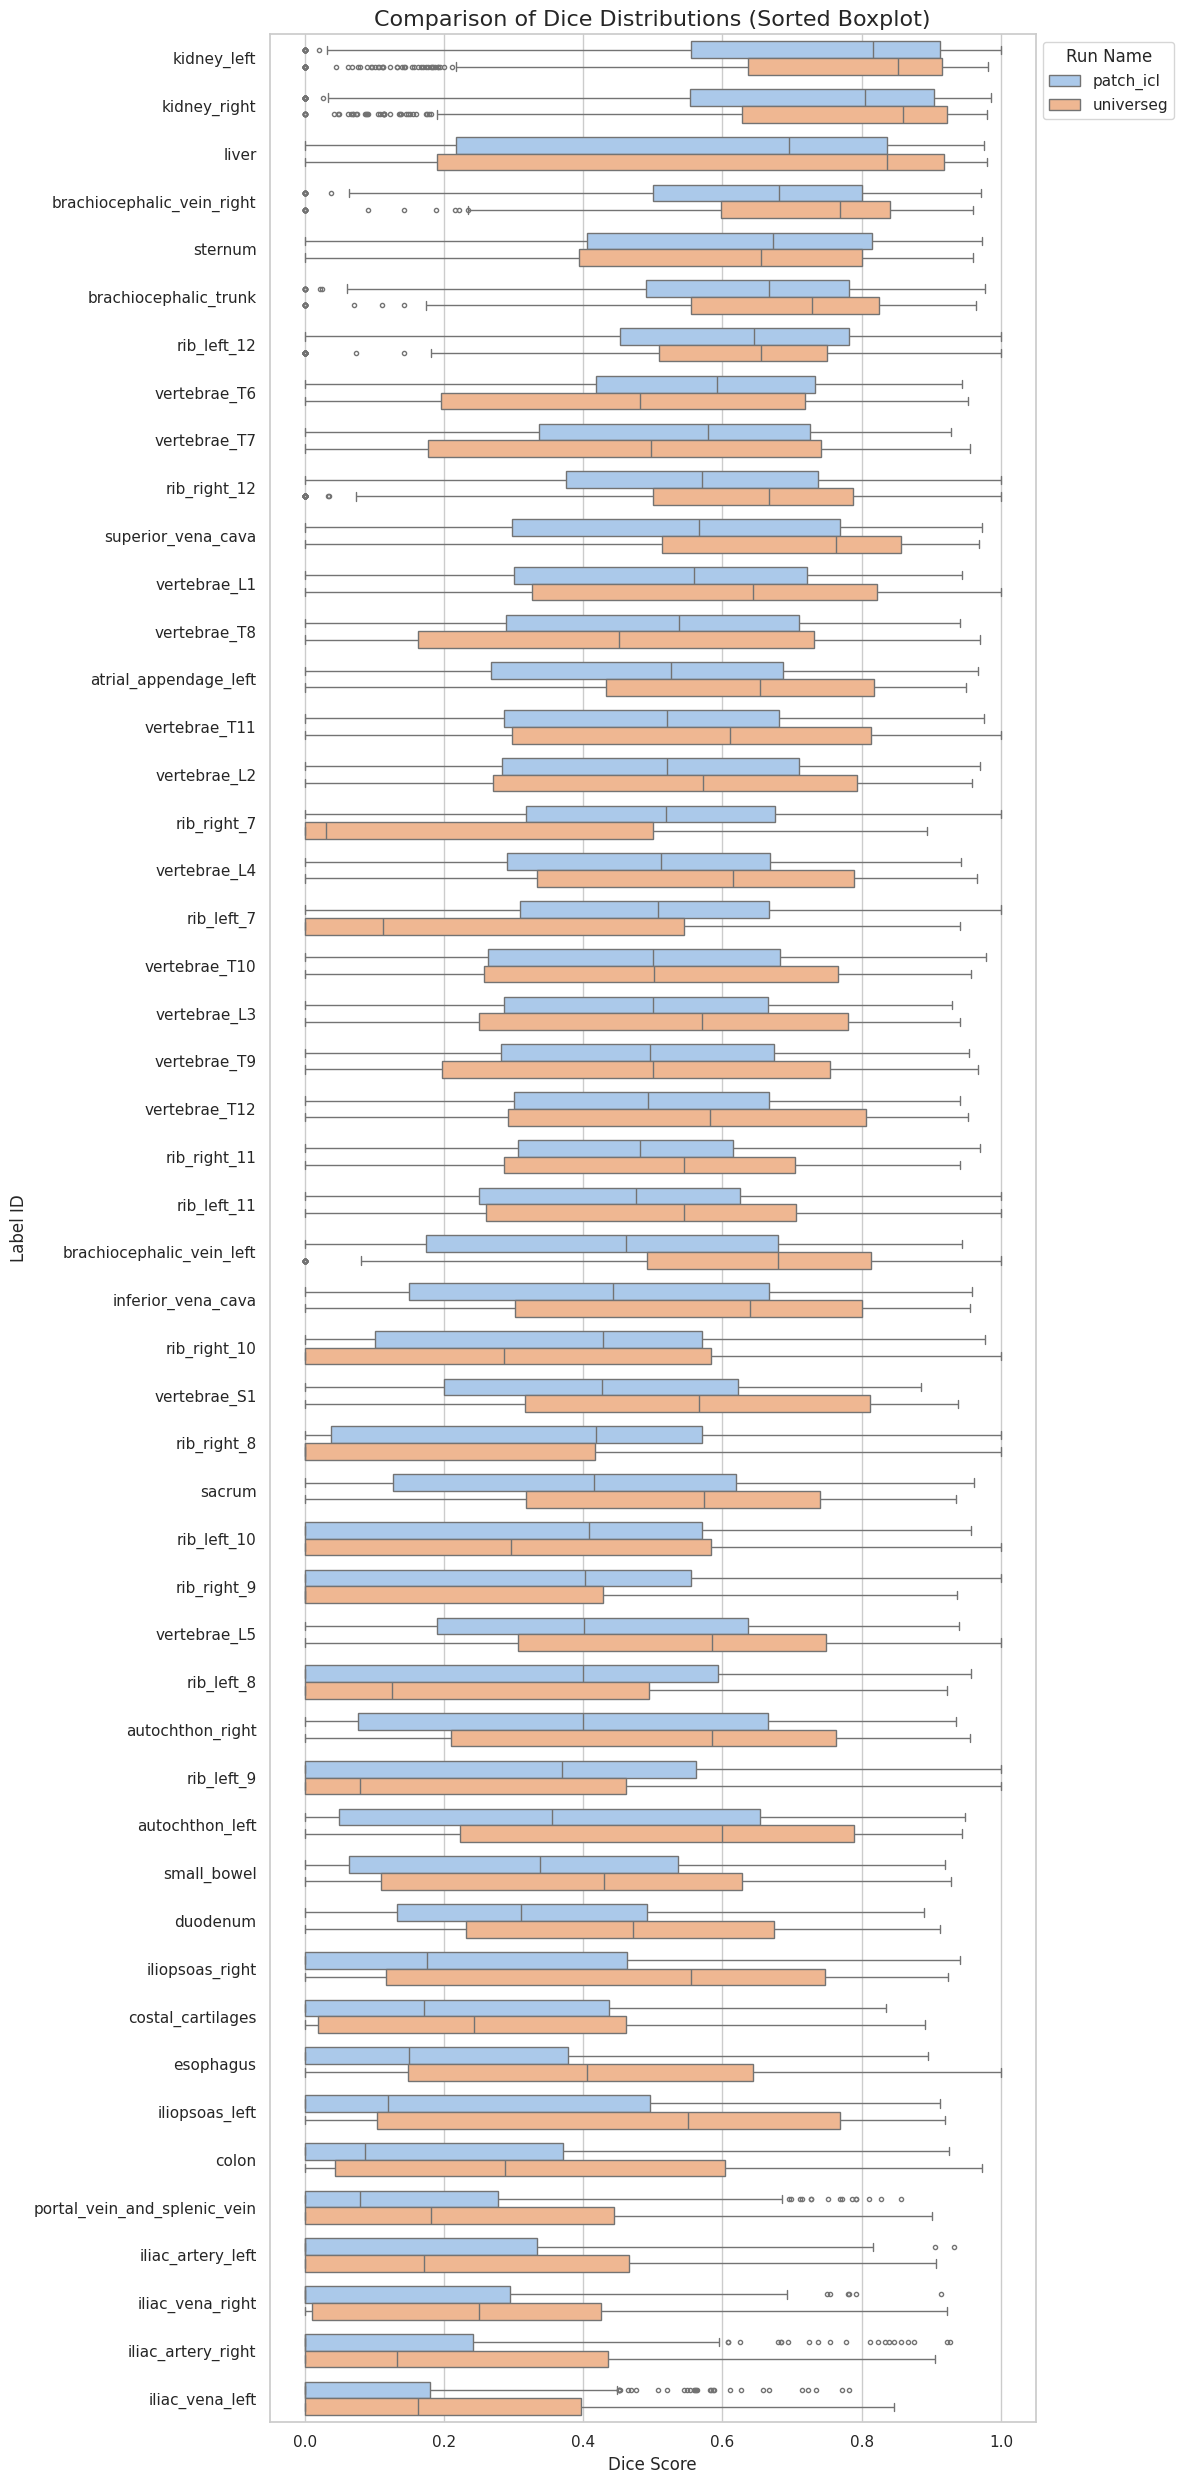

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. MERGE: Combine the two runs into a single DataFrame
combined_data = []

for run_name, run_data in runs.items():
    df_temp = run_data["df"].copy()
    # Add a column to identify the method (Run Name)
    df_temp["Run"] = run_name  
    combined_data.append(df_temp)

df_all = pd.concat(combined_data, ignore_index=True)

# 2. SORT: Calculate median Dice for the first run to sort labels
# This prevents the "random mess" look by creating a waterfall effect.
first_run_name = list(runs.keys())[0]

# Get the sort order (highest median to lowest)
sort_order = df_all[df_all['Run'] == first_run_name] \
             .groupby('label_id')['dice'].median() \
             .sort_values(ascending=False).index

# Apply the sort order to the 'label_id' column
df_all['label_id'] = pd.Categorical(
    df_all['label_id'], 
    categories=sort_order, 
    ordered=True
)

# 3. PLOT: Vertical Boxplot
# Tall height (25) is critical for 50 labels to be readable
plt.figure(figsize=(12, 25)) 
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_all,
    x="dice",           # Metric on X axis
    y="label_id",       # Labels on Y axis
    hue="Run",          # Compare the two runs side-by-side
    orient="h",         # Horizontal orientation
    palette="pastel",   # Softer colors
    width=0.7,          # Adjust box width to fit tightly
    linewidth=1.0,      # Thinner lines for clarity
    fliersize=3         # Smaller outlier dots
)

plt.title('Comparison of Dice Distributions (Sorted Boxplot)', fontsize=16)
plt.xlabel('Dice Score')
plt.ylabel('Label ID')

# Move legend outside if it covers data
plt.legend(title='Run Name', loc='upper left', bbox_to_anchor=(1, 1)) 

plt.tight_layout()
plt.show()

In [35]:
df_all.label_id.unique().tolist()

['iliac_artery_left',
 'iliac_artery_right',
 'colon',
 'small_bowel',
 'sacrum',
 'iliopsoas_left',
 'iliopsoas_right',
 'iliac_vena_left',
 'iliac_vena_right',
 'vertebrae_T6',
 'rib_left_8',
 'brachiocephalic_trunk',
 'autochthon_left',
 'rib_left_7',
 'brachiocephalic_vein_right',
 'superior_vena_cava',
 'rib_right_7',
 'sternum',
 'vertebrae_T7',
 'costal_cartilages',
 'autochthon_right',
 'esophagus',
 'brachiocephalic_vein_left',
 'vertebrae_T8',
 'atrial_appendage_left',
 'rib_right_9',
 'vertebrae_L1',
 'rib_left_9',
 'inferior_vena_cava',
 'kidney_left',
 'vertebrae_T11',
 'liver',
 'rib_right_11',
 'rib_left_11',
 'rib_left_12',
 'vertebrae_T9',
 'rib_right_12',
 'vertebrae_T10',
 'vertebrae_T12',
 'rib_right_10',
 'rib_left_10',
 'rib_right_8',
 'vertebrae_S1',
 'vertebrae_L4',
 'duodenum',
 'vertebrae_L2',
 'portal_vein_and_splenic_vein',
 'vertebrae_L3',
 'kidney_right',
 'vertebrae_L5']

In [36]:
import pickle
import numpy as np
from pathlib import Path

totalseg_dir = Path("/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/totalsegmri_2d_shared")

with open(totalseg_dir / "stats.pkl", "rb") as f:
    stats_data = pickle.load(f)

# stats_data: {case_id: {shape, spacing, modality, num_slices, labels: {label: {bbox, volume, coverage}}}}
# Compute per-label: occurrences and avg/median volume
label_agg = {}
for case_data in stats_data.values():
    for label, ldata in case_data.get("labels", {}).items():
        if label not in label_agg:
            label_agg[label] = {"occurrences": 0, "volumes": []}
        label_agg[label]["occurrences"] += 1
        label_agg[label]["volumes"].append(ldata["volume"])

rows = [
    {"label_id": lbl, "occurrences": s["occurrences"],
     "avg_volume": np.mean(s["volumes"]), "median_volume": np.median(s["volumes"])}
    for lbl, s in sorted(label_agg.items())
]
df_label_stats = pd.DataFrame(rows).set_index("label_id")
print(df_label_stats.shape)
print(df_label_stats.sort_values("occurrences", ascending=False).head(10))

(56, 3)
                      occurrences    avg_volume  median_volume
label_id                                                      
spinal_cord                   197  14972.685279         9991.0
vertebrae                     195  52887.405128        36694.0
intervertebral_discs          193  22919.119171        18461.0
colon                         179  95448.675978        66280.0
autochthon_left               178  54681.505618        41658.0
autochthon_right              177  51215.169492        38409.0
iliopsoas_right               170  45173.811765        25981.5
iliopsoas_left                166  46450.506024        26921.5
small_bowel                   154  92084.512987        57622.5
aorta                         142  19615.485915        14678.0


patch_icl - Volume Correlation (Spearman): 0.55
universeg - Volume Correlation (Spearman): 0.52
patch_icl - Occurrence Correlation (Spearman): 0.32
universeg - Occurrence Correlation (Spearman): 0.33


/tmp/ipykernel_3641632/4184586034.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_dice_avg = df_all.groupby(['label_id', 'Run'], as_index=False)['dice'].mean()


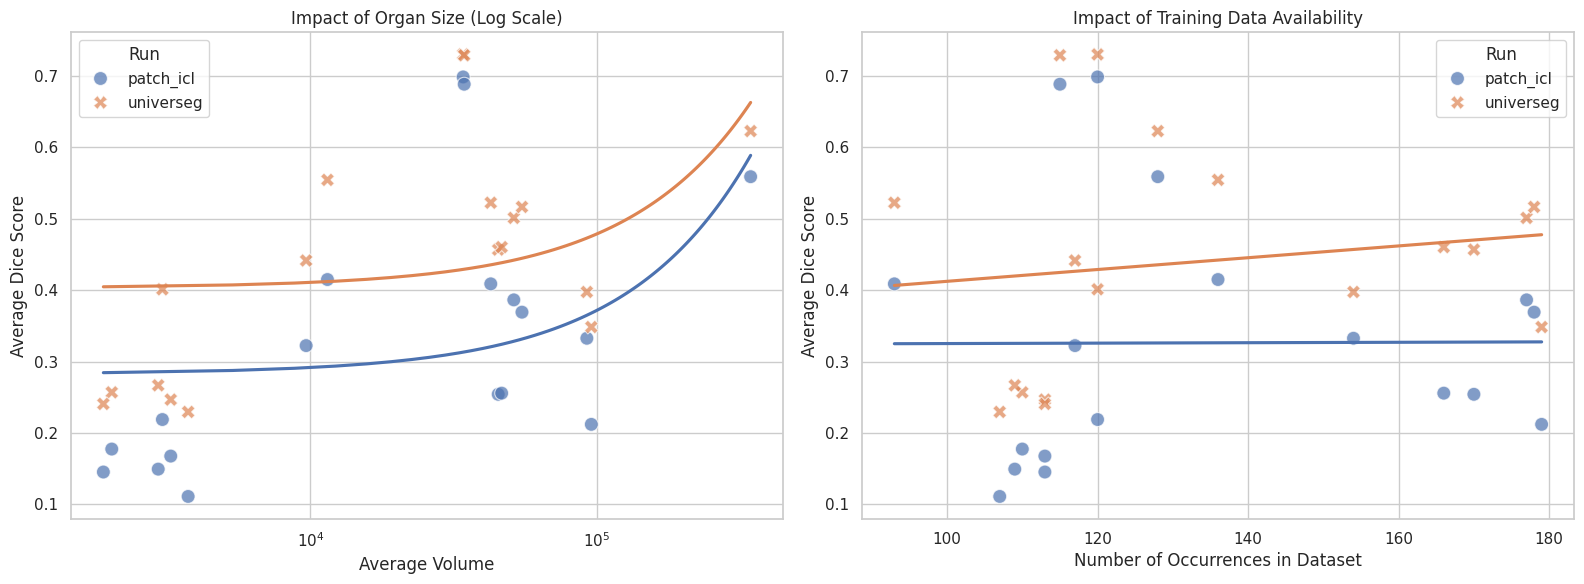

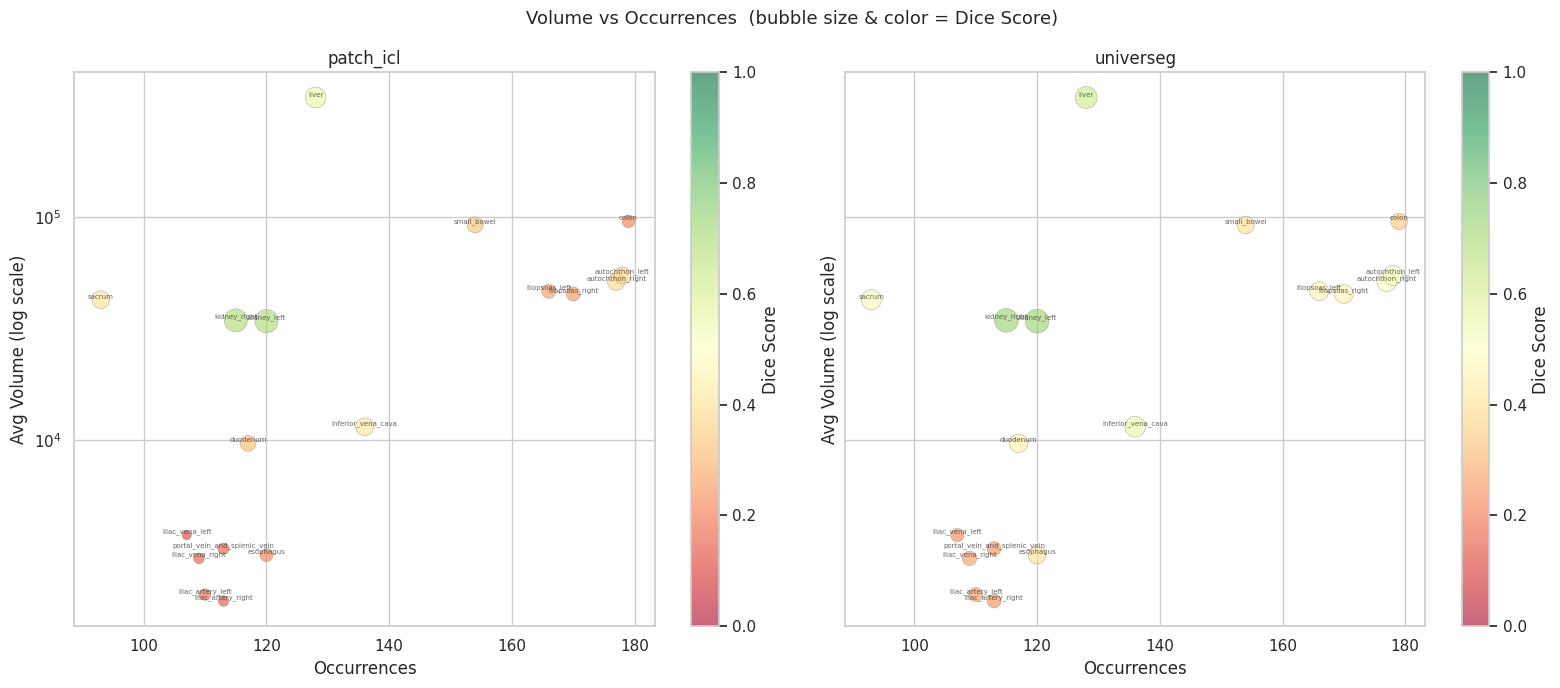

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Prepare data
df_dice_avg = df_all.groupby(['label_id', 'Run'], as_index=False)['dice'].mean()
df_final = pd.merge(df_dice_avg, df_label_stats.reset_index(), on='label_id')

# 1. Volume vs Dice
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(data=df_final, x="avg_volume", y="dice", hue="Run", style="Run", s=100, alpha=0.7, ax=axes[0])
colors = sns.color_palette()
for i, method in enumerate(df_final['Run'].unique()):
    subset = df_final[df_final['Run'] == method]
    sns.regplot(data=subset, x="avg_volume", y="dice", scatter=False, ax=axes[0], color=colors[i], ci=None)
    corr, _ = spearmanr(subset['avg_volume'], subset['dice'])
    print(f"{method} - Volume Correlation (Spearman): {corr:.2f}")
axes[0].set_xscale("log")
axes[0].set_title("Impact of Organ Size (Log Scale)")
axes[0].set_xlabel("Average Volume")
axes[0].set_ylabel("Average Dice Score")

# 2. Occurrences vs Dice
sns.scatterplot(data=df_final, x="occurrences", y="dice", hue="Run", style="Run", s=100, alpha=0.7, ax=axes[1])
for i, method in enumerate(df_final['Run'].unique()):
    subset = df_final[df_final['Run'] == method]
    sns.regplot(data=subset, x="occurrences", y="dice", scatter=False, ax=axes[1], color=colors[i], ci=None)
    corr, _ = spearmanr(subset['occurrences'], subset['dice'])
    print(f"{method} - Occurrence Correlation (Spearman): {corr:.2f}")
axes[1].set_title("Impact of Training Data Availability")
axes[1].set_xlabel("Number of Occurrences in Dataset")
axes[1].set_ylabel("Average Dice Score")

plt.tight_layout()
plt.show()

# 3. Multivariate bubble plot: volume vs occurrences, size & color = dice
fig, axes = plt.subplots(1, len(runs), figsize=(8 * len(runs), 7), sharey=True, sharex=True)
if len(runs) == 1:
    axes = [axes]

for ax, (run_name, _) in zip(axes, runs.items()):
    subset = df_final[df_final['Run'] == run_name].copy()
    sizes = (subset['dice'] * 400).clip(lower=10)
    sc = ax.scatter(
        subset['occurrences'], subset['avg_volume'],
        s=sizes, alpha=0.6, c=subset['dice'], cmap='RdYlGn',
        vmin=0, vmax=1, edgecolors='grey', linewidths=0.4
    )
    for _, row in subset.iterrows():
        ax.annotate(row['label_id'], (row['occurrences'], row['avg_volume']),
                    fontsize=5, alpha=0.7, ha='center', va='bottom')
    plt.colorbar(sc, ax=ax, label='Dice Score')
    ax.set_yscale('log')
    ax.set_title(run_name)
    ax.set_xlabel('Occurrences')
    ax.set_ylabel('Avg Volume (log scale)')

plt.suptitle('Volume vs Occurrences  (bubble size & color = Dice Score)', fontsize=13)
plt.tight_layout()
plt.show()

In [38]:
category_map_mri = {
    "esophagus": "Organs (Abd/Pelvis)", "stomach": "Organs (Abd/Pelvis)",
    "duodenum": "Organs (Abd/Pelvis)", "small_bowel": "Organs (Abd/Pelvis)",
    "colon": "Organs (Abd/Pelvis)", "liver": "Organs (Abd/Pelvis)",
    "gallbladder": "Organs (Abd/Pelvis)", "pancreas": "Organs (Abd/Pelvis)",
    "spleen": "Organs (Abd/Pelvis)", "kidney_left": "Organs (Abd/Pelvis)",
    "kidney_right": "Organs (Abd/Pelvis)", "urinary_bladder": "Organs (Abd/Pelvis)",
    "prostate": "Organs (Abd/Pelvis)", "adrenal_gland_left": "Organs (Abd/Pelvis)",
    "adrenal_gland_right": "Organs (Abd/Pelvis)",
    "heart": "Organs (Thorax/Head/Spine)", "lung_left": "Organs (Thorax/Head/Spine)",
    "lung_right": "Organs (Thorax/Head/Spine)", "brain": "Organs (Thorax/Head/Spine)",
    "spinal_cord": "Organs (Thorax/Head/Spine)",
    "vertebrae": "Bones (Spine)", "intervertebral_discs": "Bones (Spine)", "sacrum": "Bones (Spine)",
    "hip_left": "Bones (Limbs/Pelvis)", "hip_right": "Bones (Limbs/Pelvis)",
    "femur_left": "Bones (Limbs/Pelvis)", "femur_right": "Bones (Limbs/Pelvis)",
    "humerus_left": "Bones (Limbs/Pelvis)", "humerus_right": "Bones (Limbs/Pelvis)",
    "tibia": "Bones (Limbs/Pelvis)", "fibula": "Bones (Limbs/Pelvis)",
    "autochthon_left": "Muscles (Trunk)", "autochthon_right": "Muscles (Trunk)",
    "iliopsoas_left": "Muscles (Trunk)", "iliopsoas_right": "Muscles (Trunk)",
    "gluteus_maximus_left": "Muscles (Trunk)", "gluteus_maximus_right": "Muscles (Trunk)",
    "gluteus_medius_left": "Muscles (Trunk)", "gluteus_medius_right": "Muscles (Trunk)",
    "gluteus_minimus_left": "Muscles (Trunk)", "gluteus_minimus_right": "Muscles (Trunk)",
    "quadriceps_femoris_left": "Muscles (Thigh)", "quadriceps_femoris_right": "Muscles (Thigh)",
    "sartorius_left": "Muscles (Thigh)", "sartorius_right": "Muscles (Thigh)",
    "thigh_medial_compartment_left": "Muscles (Thigh)", "thigh_medial_compartment_right": "Muscles (Thigh)",
    "thigh_posterior_compartment_left": "Muscles (Thigh)", "thigh_posterior_compartment_right": "Muscles (Thigh)",
    "aorta": "Vessels", "iliac_artery_left": "Vessels", "iliac_artery_right": "Vessels",
    "inferior_vena_cava": "Vessels", "iliac_vena_left": "Vessels", "iliac_vena_right": "Vessels",
    "portal_vein_and_splenic_vein": "Vessels",
}

category_map_ct = {
    "esophagus": "Organs (Abd/Pelvis)", "stomach": "Organs (Abd/Pelvis)",
    "duodenum": "Organs (Abd/Pelvis)", "small_bowel": "Organs (Abd/Pelvis)",
    "colon": "Organs (Abd/Pelvis)", "liver": "Organs (Abd/Pelvis)",
    "gallbladder": "Organs (Abd/Pelvis)", "pancreas": "Organs (Abd/Pelvis)",
    "spleen": "Organs (Abd/Pelvis)", "kidney_left": "Organs (Abd/Pelvis)",
    "kidney_right": "Organs (Abd/Pelvis)", "urinary_bladder": "Organs (Abd/Pelvis)",
    "prostate": "Organs (Abd/Pelvis)", "adrenal_gland_right": "Organs (Abd/Pelvis)",
    "adrenal_gland_left": "Organs (Abd/Pelvis)",
    "heart": "Organs (Thorax/Head/Spine)", "trachea": "Organs (Thorax/Head/Spine)",
    "thyroid_gland": "Organs (Thorax/Head/Spine)", "brain": "Organs (Thorax/Head/Spine)",
    "spinal_cord": "Organs (Thorax/Head/Spine)", "atrial_appendage_left": "Organs (Thorax/Head/Spine)",
    "lung_upper_lobe_left": "Organs (Thorax/Head/Spine)", "lung_lower_lobe_left": "Organs (Thorax/Head/Spine)",
    "lung_upper_lobe_right": "Organs (Thorax/Head/Spine)", "lung_middle_lobe_right": "Organs (Thorax/Head/Spine)",
    "lung_lower_lobe_right": "Organs (Thorax/Head/Spine)",
    "aorta": "Vessels", "iliac_artery_left": "Vessels", "iliac_artery_right": "Vessels",
    "subclavian_artery_left": "Vessels", "subclavian_artery_right": "Vessels",
    "superior_vena_cava": "Vessels", "inferior_vena_cava": "Vessels",
    "brachiocephalic_vein_left": "Vessels", "iliac_vena_left": "Vessels",
    "iliac_vena_right": "Vessels", "pulmonary_vein": "Vessels",
    "portal_vein_and_splenic_vein": "Vessels", "common_carotid_artery_left": "Vessels",
    "common_carotid_artery_right": "Vessels", "brachiocephalic_vein_right": "Vessels",
    "brachiocephalic_trunk": "Vessels",
    "autochthon_left": "Muscles", "autochthon_right": "Muscles",
    "iliopsoas_left": "Muscles", "iliopsoas_right": "Muscles",
    "gluteus_maximus_left": "Muscles", "gluteus_maximus_right": "Muscles",
    "gluteus_medius_left": "Muscles", "gluteus_medius_right": "Muscles",
    "gluteus_minimus_left": "Muscles", "gluteus_minimus_right": "Muscles",
}

# Detect modality: MRI map has 'vertebrae', 'lung_left' (no lobe suffix)
labels_in_data = set(df_all['label_id'].unique())
use_mri_map = bool(labels_in_data & {'vertebrae', 'intervertebral_discs', 'lung_left', 'lung_right'})
cat_map = category_map_mri if use_mri_map else category_map_ct
print(f"Using {'MRI' if use_mri_map else 'CT'} category map\n")

df_all['category'] = df_all['label_id'].map(cat_map).fillna('Other')

# --- Per-label table ---
label_stats = (
    df_all.groupby(['Run', 'label_id'])['dice']
    .agg(mean='mean', std='std')
    .reset_index()
    .sort_values(['Run', 'mean'], ascending=[True, False])
)

print("=" * 60)
print("DICE BY LABEL")
print("=" * 60)
for run_name, grp in label_stats.groupby('Run'):
    print(f"\n--- {run_name} ---")
    print(f"{'Label':<45} {'Mean':>6}  {'Std':>6}")
    print("-" * 60)
    for _, row in grp.iterrows():
        print(f"{row['label_id']:<45} {row['mean']:>6.3f}  {row['std']:>6.3f}")
    overall_mean = df_all[df_all['Run'] == run_name]['dice'].mean()
    overall_std  = df_all[df_all['Run'] == run_name]['dice'].std()
    print(f"\n{'OVERALL':<45} {overall_mean:>6.3f}  {overall_std:>6.3f}")

# --- Per-category table ---
cat_stats = (
    df_all.groupby(['Run', 'category'])['dice']
    .agg(mean='mean', std='std')
    .reset_index()
    .sort_values(['Run', 'mean'], ascending=[True, False])
)

print("\n\n" + "=" * 60)
print("DICE BY CATEGORY")
print("=" * 60)
for run_name, grp in cat_stats.groupby('Run'):
    print(f"\n--- {run_name} ---")
    print(f"{'Category':<35} {'Mean':>6}  {'Std':>6}")
    print("-" * 48)
    for _, row in grp.iterrows():
        print(f"{row['category']:<35} {row['mean']:>6.3f}  {row['std']:>6.3f}")


Using CT category map

DICE BY LABEL

--- patch_icl ---
Label                                           Mean     Std
------------------------------------------------------------
kidney_left                                    0.699   0.278
kidney_right                                   0.689   0.289
brachiocephalic_vein_right                     0.627   0.225
brachiocephalic_trunk                          0.615   0.220
sternum                                        0.599   0.253
rib_left_12                                    0.595   0.248
liver                                          0.559   0.331
vertebrae_T6                                   0.552   0.233
rib_right_12                                   0.531   0.256
vertebrae_T7                                   0.529   0.246
superior_vena_cava                             0.525   0.285
vertebrae_L1                                   0.517   0.252
vertebrae_L2                                   0.498   0.252
vertebrae_T8                 

/tmp/ipykernel_3641632/3369838573.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_all.groupby(['Run', 'label_id'])['dice']


In [39]:
category_map_mri = {
    "esophagus": "Organs (Abd/Pelvis)", "stomach": "Organs (Abd/Pelvis)",
    "duodenum": "Organs (Abd/Pelvis)", "small_bowel": "Organs (Abd/Pelvis)",
    "colon": "Organs (Abd/Pelvis)", "liver": "Organs (Abd/Pelvis)",
    "gallbladder": "Organs (Abd/Pelvis)", "pancreas": "Organs (Abd/Pelvis)",
    "spleen": "Organs (Abd/Pelvis)", "kidney_left": "Organs (Abd/Pelvis)",
    "kidney_right": "Organs (Abd/Pelvis)", "urinary_bladder": "Organs (Abd/Pelvis)",
    "prostate": "Organs (Abd/Pelvis)", "adrenal_gland_left": "Organs (Abd/Pelvis)",
    "adrenal_gland_right": "Organs (Abd/Pelvis)",
    "heart": "Organs (Thorax/Head/Spine)", "lung_left": "Organs (Thorax/Head/Spine)",
    "lung_right": "Organs (Thorax/Head/Spine)", "brain": "Organs (Thorax/Head/Spine)",
    "spinal_cord": "Organs (Thorax/Head/Spine)",
    "vertebrae": "Bones (Spine)", "intervertebral_discs": "Bones (Spine)", "sacrum": "Bones (Spine)",
    "hip_left": "Bones (Limbs/Pelvis)", "hip_right": "Bones (Limbs/Pelvis)",
    "femur_left": "Bones (Limbs/Pelvis)", "femur_right": "Bones (Limbs/Pelvis)",
    "humerus_left": "Bones (Limbs/Pelvis)", "humerus_right": "Bones (Limbs/Pelvis)",
    "tibia": "Bones (Limbs/Pelvis)", "fibula": "Bones (Limbs/Pelvis)",
    "autochthon_left": "Muscles (Trunk)", "autochthon_right": "Muscles (Trunk)",
    "iliopsoas_left": "Muscles (Trunk)", "iliopsoas_right": "Muscles (Trunk)",
    "gluteus_maximus_left": "Muscles (Trunk)", "gluteus_maximus_right": "Muscles (Trunk)",
    "gluteus_medius_left": "Muscles (Trunk)", "gluteus_medius_right": "Muscles (Trunk)",
    "gluteus_minimus_left": "Muscles (Trunk)", "gluteus_minimus_right": "Muscles (Trunk)",
    "quadriceps_femoris_left": "Muscles (Thigh)", "quadriceps_femoris_right": "Muscles (Thigh)",
    "sartorius_left": "Muscles (Thigh)", "sartorius_right": "Muscles (Thigh)",
    "thigh_medial_compartment_left": "Muscles (Thigh)", "thigh_medial_compartment_right": "Muscles (Thigh)",
    "thigh_posterior_compartment_left": "Muscles (Thigh)", "thigh_posterior_compartment_right": "Muscles (Thigh)",
    "aorta": "Vessels", "iliac_artery_left": "Vessels", "iliac_artery_right": "Vessels",
    "inferior_vena_cava": "Vessels", "iliac_vena_left": "Vessels", "iliac_vena_right": "Vessels",
    "portal_vein_and_splenic_vein": "Vessels",
}

category_map_ct = {
    "esophagus": "Organs (Abd/Pelvis)", "stomach": "Organs (Abd/Pelvis)",
    "duodenum": "Organs (Abd/Pelvis)", "small_bowel": "Organs (Abd/Pelvis)",
    "colon": "Organs (Abd/Pelvis)", "liver": "Organs (Abd/Pelvis)",
    "gallbladder": "Organs (Abd/Pelvis)", "pancreas": "Organs (Abd/Pelvis)",
    "spleen": "Organs (Abd/Pelvis)", "kidney_left": "Organs (Abd/Pelvis)",
    "kidney_right": "Organs (Abd/Pelvis)", "urinary_bladder": "Organs (Abd/Pelvis)",
    "prostate": "Organs (Abd/Pelvis)", "adrenal_gland_right": "Organs (Abd/Pelvis)",
    "adrenal_gland_left": "Organs (Abd/Pelvis)",
    "heart": "Organs (Thorax/Head/Spine)", "trachea": "Organs (Thorax/Head/Spine)",
    "thyroid_gland": "Organs (Thorax/Head/Spine)", "brain": "Organs (Thorax/Head/Spine)",
    "spinal_cord": "Organs (Thorax/Head/Spine)", "atrial_appendage_left": "Organs (Thorax/Head/Spine)",
    "lung_upper_lobe_left": "Organs (Thorax/Head/Spine)", "lung_lower_lobe_left": "Organs (Thorax/Head/Spine)",
    "lung_upper_lobe_right": "Organs (Thorax/Head/Spine)", "lung_middle_lobe_right": "Organs (Thorax/Head/Spine)",
    "lung_lower_lobe_right": "Organs (Thorax/Head/Spine)",
    "aorta": "Vessels", "iliac_artery_left": "Vessels", "iliac_artery_right": "Vessels",
    "subclavian_artery_left": "Vessels", "subclavian_artery_right": "Vessels",
    "superior_vena_cava": "Vessels", "inferior_vena_cava": "Vessels",
    "brachiocephalic_vein_left": "Vessels", "iliac_vena_left": "Vessels",
    "iliac_vena_right": "Vessels", "pulmonary_vein": "Vessels",
    "portal_vein_and_splenic_vein": "Vessels", "common_carotid_artery_left": "Vessels",
    "common_carotid_artery_right": "Vessels", "brachiocephalic_vein_right": "Vessels",
    "brachiocephalic_trunk": "Vessels",
    "autochthon_left": "Muscles", "autochthon_right": "Muscles",
    "iliopsoas_left": "Muscles", "iliopsoas_right": "Muscles",
    "gluteus_maximus_left": "Muscles", "gluteus_maximus_right": "Muscles",
    "gluteus_medius_left": "Muscles", "gluteus_medius_right": "Muscles",
    "gluteus_minimus_left": "Muscles", "gluteus_minimus_right": "Muscles",
}

labels_in_data = set(df_all['label_id'].unique())
use_mri_map = bool(labels_in_data & {'vertebrae', 'intervertebral_discs', 'lung_left', 'lung_right'})
cat_map = category_map_mri if use_mri_map else category_map_ct
print(f"Using {'MRI' if use_mri_map else 'CT'} category map\n")

df_all['category'] = df_all['label_id'].map(cat_map).fillna('Other')

label_stats = (
    df_all.groupby(['Run', 'label_id'])['dice']
    .agg(mean='mean', std='std')
    .reset_index()
    .sort_values(['Run', 'mean'], ascending=[True, False])
)

print("=" * 60)
print("DICE BY LABEL")
print("=" * 60)
for run_name, grp in label_stats.groupby('Run'):
    print(f"\n--- {run_name} ---")
    print(f"{'Label':<45} {'Mean':>6}  {'Std':>6}")
    print("-" * 60)
    for _, row in grp.iterrows():
        print(f"{row['label_id']:<45} {row['mean']:>6.3f}  {row['std']:>6.3f}")
    overall_mean = df_all[df_all['Run'] == run_name]['dice'].mean()
    overall_std  = df_all[df_all['Run'] == run_name]['dice'].std()
    print(f"\n{'OVERALL':<45} {overall_mean:>6.3f}  {overall_std:>6.3f}")

cat_stats = (
    df_all.groupby(['Run', 'category'])['dice']
    .agg(mean='mean', std='std')
    .reset_index()
    .sort_values(['Run', 'mean'], ascending=[True, False])
)

print("\n\n" + "=" * 60)
print("DICE BY CATEGORY")
print("=" * 60)
for run_name, grp in cat_stats.groupby('Run'):
    print(f"\n--- {run_name} ---")
    print(f"{'Category':<35} {'Mean':>6}  {'Std':>6}")
    print("-" * 48)
    for _, row in grp.iterrows():
        print(f"{row['category']:<35} {row['mean']:>6.3f}  {row['std']:>6.3f}")


Using CT category map

DICE BY LABEL

--- patch_icl ---
Label                                           Mean     Std
------------------------------------------------------------
kidney_left                                    0.699   0.278
kidney_right                                   0.689   0.289
brachiocephalic_vein_right                     0.627   0.225
brachiocephalic_trunk                          0.615   0.220
sternum                                        0.599   0.253
rib_left_12                                    0.595   0.248
liver                                          0.559   0.331
vertebrae_T6                                   0.552   0.233
rib_right_12                                   0.531   0.256
vertebrae_T7                                   0.529   0.246
superior_vena_cava                             0.525   0.285
vertebrae_L1                                   0.517   0.252
vertebrae_L2                                   0.498   0.252
vertebrae_T8                 

/tmp/ipykernel_3641632/3608539620.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_all.groupby(['Run', 'label_id'])['dice']
